In [1]:
import numpy as np

In [2]:
I = np.eye(2)
X = np.array([[0,1],[1,0]])
Y = np.array([[0,-1j],[1j,0]])
Z = np.array([[1,0],[0,-1]])
def selection(input_element = str):
    if "I" == input_element:
        return I
    if "X" == input_element:
        return X    
    if "Y" == input_element:
        return Y
    if "Z" == input_element:
        return Z
    else:
        raise ValueError("Input Flawed")
def tensor_string(product_input):
    tensor_product = selection(product_input[0])
    for i in product_input[1:]:
        tensor_product = np.kron(tensor_product, selection(i))
    
    return tensor_product

def tensor_loop(op, num):
    mat = op
    if num == 0:
        return 1
    for _ in range(num-1):
        mat = np.kron(mat, op)
    
    return mat

def weight_set(op, length):
    set_list = []
    for i in range(length):
        #print(i, length-i-1)
        set_list.append(np.kron(np.kron(tensor_loop(I,i),op), tensor_loop(I,length-i-1)))
        
    return set_list

def weight_op(op, input = None):
    print(int(np.log2((np.shape((input))[0]))))
    set_ops = weight_set(op, int(np.log2((np.shape((input))[0]))))
    weight_sum = 0
    for op_set in set_ops:
        eig_vals, eig_vecs = np.linalg.eigh(op_set)
        N = len(eig_vecs)
        k = 0
        for vecs in eig_vecs.T:
            weight_sum += np.abs(vecs.T @ input @ vecs)
            print(weight_sum)
    return np.round(weight_sum, 1)


weight_op(X, tensor_string("YX"))


2
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


0.0

ERROR! Session/line number was not unique in database. History logging moved to new session 79


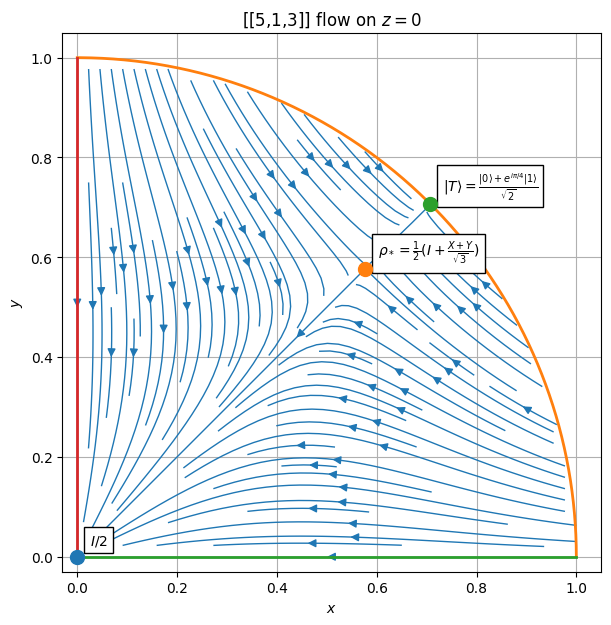

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def five_qubit_map_z0(x, y):
    P = 1 + 5*x**2*y**2
    xp = (5*x*y**2 - x**5)/P
    yp = (5*x**2*y - y**5)/P
    return xp, yp

def plot_z0_top_right_streamlines(grid_size=300):
    x_vals = np.linspace(0, 1, grid_size)
    y_vals = np.linspace(0, 1, grid_size)
    X, Y = np.meshgrid(x_vals, y_vals)

    XP, YP = five_qubit_map_z0(X, Y)

    U = XP - X
    V = YP - Y

    outside = X**2 + Y**2 > 1
    U = np.ma.array(U, mask=outside)
    V = np.ma.array(V, mask=outside)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.streamplot(
        X,
        Y,
        U,
        V,
        density=1.5,
        linewidth=1.0,
        arrowsize=1.2)

    theta = np.linspace(0, np.pi / 2, 500)
    ax.plot(np.cos(theta), np.sin(theta), linewidth=2)


    ax.plot([0, 1], [0, 0], linewidth=2)
    ax.plot([0, 0], [0, 1], linewidth=2)


    fixed_points = {
        r"$I/2$": (0, 0),
        r"$\rho_*=\frac{1}{2}(I+\frac{X+Y}{\sqrt{3}})$": (1/np.sqrt(3), 1/np.sqrt(3)),
        r"$|T\rangle=\frac{|0\rangle+e^{i\pi/4}|1\rangle}{\sqrt{2}}$": (1/np.sqrt(2), 1/np.sqrt(2)),
    }

    for label, (x, y) in fixed_points.items():
        ax.scatter(x, y, s=100, zorder=5)
        ax.text(x + 0.025, y + 0.025, label, fontsize=10, 
        bbox=dict(facecolor='white', alpha=1.0, edgecolor='black'))

    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_title(r"[[5,1,3]] flow on $z=0$")

    ax.set_xlim(-0.03, 1.05)
    ax.set_ylim(-0.03, 1.05)
    ax.set_aspect("equal")
    ax.grid(True)
    plt.savefig("513stream.pdf")
    plt.show()


plot_z0_top_right_streamlines()

In [ ]:
def multiply_paulis(p1, p2):


    if len(p1) != len(p2):
        raise ValueError("Pauli strings must have the same length")


    rules = {
        ("I", "I"): (1, "I"),
        ("I", "X"): (1, "X"),
        ("I", "Y"): (1, "Y"),
        ("I", "Z"): (1, "Z"),

        ("X", "I"): (1, "X"),
        ("Y", "I"): (1, "Y"),
        ("Z", "I"): (1, "Z"),

        ("X", "X"): (1, "I"),
        ("Y", "Y"): (1, "I"),
        ("Z", "Z"): (1, "I"),

        ("X", "Y"): (1j, "Z"),
        ("Y", "X"): (-1j, "Z"),

        ("Y", "Z"): (1j, "X"),
        ("Z", "Y"): (-1j, "X"),

        ("Z", "X"): (1j, "Y"),
        ("X", "Z"): (-1j, "Y"),
    }

    total_phase = 1
    result = ""

    for a, b in zip(p1, p2):
        phase, c = rules[(a, b)]
        total_phase *= phase
        result += c

    return total_phase, result


def format_pauli_product(phase, pauli_string):
    if phase == 1:
        return pauli_string
    elif phase == -1:
        return "-" + pauli_string
    elif phase == 1j:
        return "i" + pauli_string
    elif phase == -1j:
        return "-i" + pauli_string
    else:
        return f"{phase} {pauli_string}"


p1 = "YZIZY"
p2 = "YYYYY"

phase, result = multiply_paulis(p1, p2)

print(format_pauli_product(-phase, result))

IXYXI


<h1>Fixed Points</h1>

In [ ]:
import sympy as sp


x, y = sp.symbols("x y", real=True)

eq1 = x * (1 + x**4 + 5*x**2*y**2 - 5*y**2)
eq2 = y * (1 + y**4 + 5*x**2*y**2 - 5*x**2)


solutions = sp.solve([eq1, eq2], [x, y], dict=True)


print("Exact solutions:")
for sol in solutions:
    print(sol)


print("\nNumerical solutions:")
for sol in solutions:
    print({
        x: sp.N(sol[x]),
        y: sp.N(sol[y])
    })

Exact solutions:
{x: 0, y: 0}
{x: -sqrt(2)/2, y: -sqrt(2)/2}
{x: -sqrt(2)/2, y: sqrt(2)/2}
{x: sqrt(2)/2, y: -sqrt(2)/2}
{x: sqrt(2)/2, y: sqrt(2)/2}
{x: -sqrt(3)/3, y: -sqrt(3)/3}
{x: -sqrt(3)/3, y: sqrt(3)/3}
{x: sqrt(3)/3, y: -sqrt(3)/3}
{x: sqrt(3)/3, y: sqrt(3)/3}

Numerical solutions:
{x: 0, y: 0}
{x: -0.707106781186548, y: -0.707106781186548}
{x: -0.707106781186548, y: 0.707106781186548}
{x: 0.707106781186548, y: -0.707106781186548}
{x: 0.707106781186548, y: 0.707106781186548}
{x: -0.577350269189626, y: -0.577350269189626}
{x: -0.577350269189626, y: 0.577350269189626}
{x: 0.577350269189626, y: -0.577350269189626}
{x: 0.577350269189626, y: 0.577350269189626}


<h1>Jacobian for [[3,1,1]]</h1>

In [ ]:
import sympy as sp
import numpy as np

t = sp.symbols('t')


s = sp.sin(t)
c = sp.cos(t)


den = 1 + c*s + s**2*c


v = sp.Matrix([
    (s*c + c**2) / den,
    (s + c*s + s**2*c) / den
])


dv_dt = v.diff(t)


w = sp.Matrix([[c, -s]])

M = sp.simplify(dv_dt * w)


t_value = np.arctan(np.sqrt(((np.sqrt(5)-1)/2)))  

M_num = M.subs(t, t_value)

print(f"\nMatrix after substituting t = {t_value}:")
sp.pprint(M_num.evalf())

eigenvalues = M_num.eigenvals()

print("\nEigenvalues:")
for eig, mult in eigenvalues.items():
    print("eigenvalue =", eig.evalf(), " multiplicity =", mult)


Matrix after substituting t = 0.6662394324925153:
⎡-0.531599504991694  0.417917683264385 ⎤
⎢                                      ⎥
⎣0.417917683264384   -0.328546562487486⎦

Eigenvalues:
eigenvalue = -0.860146067479180  multiplicity = 1
eigenvalue = 2.20016146834833e-17  multiplicity = 1
